In [13]:
# ==========================================
# 06_prediccion.ipynb - Predicción final con Stacking
# ==========================================
import joblib
import os
import pandas as pd

# 1. Cargar el modelo de Stacking
ruta_modelos = '/content/drive/MyDrive/Smoking_prediction_models/'
ruta_stacking = os.path.join(ruta_modelos, 'Stacking_model.pkl')
modelo_stacking = joblib.load(ruta_stacking)

# 2. Cargar los datos sin etiquetar
ruta_datos = '/content/drive/My Drive/Training_And_Testing_Dataset/smoking_prediction_entrega_processed.csv'
df_entrega = pd.read_csv(ruta_datos)

# 3. Mostrar solo los encabezados de las columnas (para verificar estructura)
print("📌 Estructura de las columnas en el dataset de test:")
print(list(df_entrega.columns))
print("-" * 50)

# 4. Aplicar las mismas transformaciones (Ajusta según lo que usaste en tu entrenamiento)
# Si entrenaste con un Pipeline, esto ya incluye el escalado automáticamente
X_entrega = df_entrega.drop(columns=['ID'], errors='ignore')

# 5. Generar las predicciones
predicciones = modelo_stacking.predict(X_entrega)

# 6. Crear el DataFrame final con la columna requerida
df_resultado = pd.DataFrame({
    'ID': df_entrega['ID'],
    'smoking_prediction': predicciones # Se crea la columna exactamente como pide la consigna
})
# 7. Exportar
ruta_salida = '/content/drive/My Drive/Training_And_Testing_Dataset//resultado_entrega_final.csv'
df_resultado.to_csv(ruta_salida, index=False)

print(f"\n🚀 Archivo de entrega guardado en: {ruta_salida}")

📌 Estructura de las columnas en el dataset de test:
['ID', 'gender', 'age', 'height(cm)', 'weight(kg)', 'waist(cm)', 'eyesight(left)', 'eyesight(right)', 'hearing(left)', 'hearing(right)', 'systolic', 'relaxation', 'fasting blood sugar', 'Cholesterol', 'triglyceride', 'HDL', 'LDL', 'hemoglobin', 'Urine protein', 'serum creatinine', 'AST', 'ALT', 'Gtp', 'dental caries', 'tartar']
--------------------------------------------------

🚀 Archivo de entrega guardado en: /content/drive/My Drive/Training_And_Testing_Dataset//resultado_entrega_final.csv


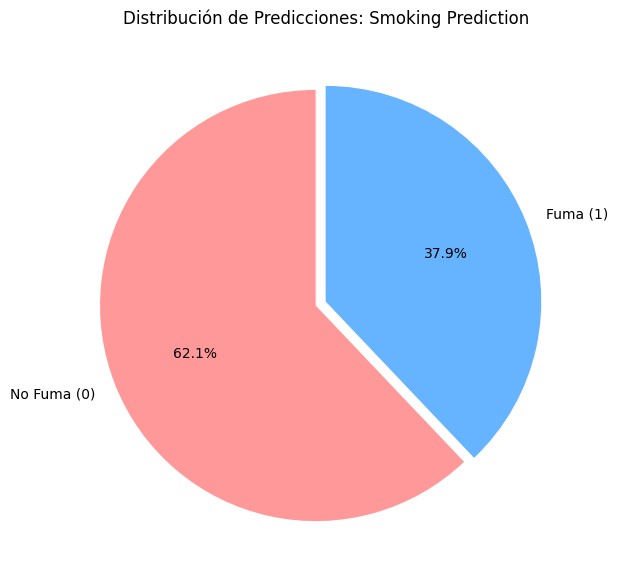

In [14]:
# ==========================================
# 06_prediccion.ipynb - Visualización Final
# ==========================================
import matplotlib.pyplot as plt



# 2. Generar gráfico de torta (Pie Chart) de los resultados
# Contamos cuántos fuman (1) vs no fuman (0)
conteo = df_resultado['smoking_prediction'].value_counts()
labels = ['No Fuma (0)', 'Fuma (1)']
colores = ['#ff9999', '#66b3ff']

plt.figure(figsize=(7, 7))
plt.pie(conteo, labels=labels, autopct='%1.1f%%', startangle=90, colors=colores, explode=(0.05, 0))
plt.title('Distribución de Predicciones: Smoking Prediction')
plt.show()